Me falta

    graficar umap y guardarlo
    mirar cuantas dimensiones

    sacar espectros de los outliers
    graficar espectros de los outliers

    actualizar el web

In [13]:
import numpy as np

In [58]:
import os
fn = '20211110-10256-0.h5'
os.path.basename(fn).split('-')[-1].split('.')[0]

'0'

In [59]:
file = np.load('./data/processed/umap/umap_20211110_10256.npz', allow_pickle=True)

In [60]:
file.files

['embedding', 'labels', 'outlier_mask', 'categories', 'ids', 'petals']

In [61]:
file['categories']

array(['Q', 'G', 'G', ..., 'Q', 'G', 'G'], dtype='<U1')

In [10]:
import matplotlib.pyplot as plt

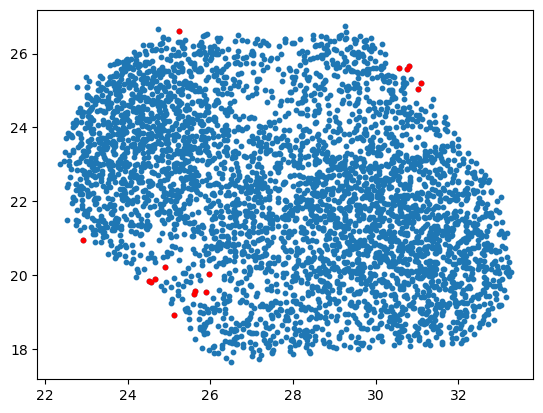

In [11]:
plt.scatter(file['embedding'][:, 0], file['embedding'][:, 1], s=10)
plt.scatter(file['embedding'][:, 0][file['outlier_mask']], file['embedding'][:, 1][file['outlier_mask']], s=10, c='red')

In [15]:
np.unique(file['categories'])

array(['G', 'O', 'Q', 'S'], dtype='<U1')

In [16]:
import sys, os
project_root = os.path.abspath('..')
sys.path.insert(0, project_root)

from src.desiproc.build_matrix import build_matrix
import glob

out_dir = os.path.join(project_root, 'AssessingDesiData', 'data', 'processed')
night   = '20211110'
tile    = '10256'
bands   = ['B','R','Z']
wg, fp, iv, z, ze, ids, cat, petals = build_matrix(out_dir, night, tile, bands)

print("wave_grid:", wg.shape)
print("flux matrix:", fp.shape)
print("ivar matrix:", iv.shape)
print("z vector:", z.shape)
print("zerr vector:", ze.shape)
print("ids vector:", ids.shape)
print("cat matrix:", cat.shape)
print("petals matrix:", petals.shape)

wave_grid: (7958,)
flux matrix: (4196, 7958)
ivar matrix: (4196, 7958)
z vector: (4196,)
zerr vector: (4196,)
ids vector: (4196,)
cat matrix: (4196,)
petals matrix: (4196,)


In [17]:
import umap
from sklearn.neighbors import radius_neighbors_graph
from scipy.sparse.csgraph import connected_components

In [18]:
defaults = dict(n_neighbors=45, min_dist=1.0, n_components=3,
                        metric='cosine', n_jobs=-1)
reducer = umap.UMAP(**defaults)
emb = reducer.fit_transform(fp)

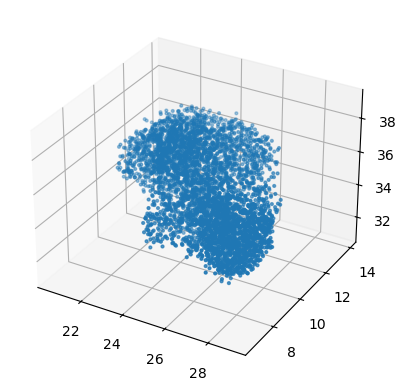

In [22]:
ax = plt.figure().add_subplot(projection='3d')
ax.scatter(emb[:, 0], emb[:, 1], emb[:, 2], 'o', s=4)

In [48]:
link_length = 0.45

In [49]:
graph = radius_neighbors_graph(emb, radius=link_length,
                                       mode='connectivity', include_self=True,
                                       n_jobs=-1)
n_clusters, labels = connected_components(csgraph=graph,
                                                            directed=False,
                                                            return_labels=True)

In [50]:
min_cluster_size = 5

In [51]:
uniq, cnt = np.unique(labels, return_counts=True)
small = uniq[cnt <= min_cluster_size]
a = np.isin(labels, small)

In [52]:
ii = 0
for aa in a:
    if aa:
        ii += 1
ii, emb.shape, (ii/emb.shape[0])*100

(23, (4196, 3), 0.548141086749285)

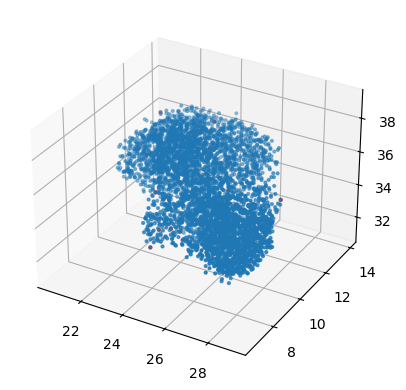

In [56]:
ax = plt.figure().add_subplot(projection='3d')
ax.scatter(emb[:, 0], emb[:, 1], emb[:, 2], 'o', s=4)
ax.scatter(emb[:, 0][a], emb[:, 1][a], emb[:, 2][a], 'o', c='red', s=4)

In [47]:
ids[a].shape

(93,)